In [14]:
# Preliminaries -----------------------------------------------------------
if (!require("pacman")) install.packages("pacman")
pacman::p_load(tidyverse, ggplot2, dplyr, lubridate, haven)

library(knitr)
library(kableExtra)

In [15]:
hcris_kff <- read_csv("../data/output/hcris_kff.csv")

Rows: 161060 Columns: 46
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (10): provider_number, data_source, street, city, state, zip, county, n...
dbl  (31): beds, tot_charges, net_pat_rev, tot_discounts, tot_operating_exp,...
date  (5): fy_start, fy_end, date_processed, date_created, expansion_date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


## Problem 1

In [16]:
hcris.kff <- hcris_kff %>% 
  mutate(
    Year = year,
    uncomp_care_m = uncomp_care / 1e6
  )
hcris.kff %>%
  filter(Year >= 2010, Year <= 2018) %>%
  group_by(Year) %>%
  summarize(
    Mean = mean(uncomp_care_m, na.rm = TRUE),
    SD   = sd(uncomp_care_m,   na.rm = TRUE),
    .groups = "drop"
  ) %>%
  kable(
    col.names = c("Year", "Mean ($M)", "Std. Dev. ($M)"),
    digits    = 2,
    booktabs  = TRUE,
    row.names = FALSE,
    caption   = "Uncompensated Care (\\$M), 2010--2018"
  ) %>%
  kable_styling(latex_options = c("hold_position", "striped")) %>%
  column_spec(1, bold = TRUE) %>%
  row_spec(0, bold = TRUE)

<table class="table" style="margin-left: auto; margin-right: auto;">
<caption>Uncompensated Care (\$M), 2010--2018</caption>
 <thead>
  <tr>
   <th style="text-align:right;font-weight: bold;"> Year </th>
   <th style="text-align:right;font-weight: bold;"> Mean ($M) 
   </th>
<th style="text-align:right;font-weight: bold;"> Std. Dev. ($M) </th>
  
 

</tr>
</thead>
<tbody>
  <tr>
   <td style="text-align:right;font-weight: bold;"> 2010 </td>
   <td style="text-align:right;"> 30.26 </td>
   <td style="text-align:right;"> 72.26 </td>
  </tr>
  <tr>
   <td style="text-align:right;font-weight: bold;"> 2011 </td>
   <td style="text-align:right;"> 34.10 </td>
   <td style="text-align:right;"> 74.96 </td>
  </tr>
  <tr>
   <td style="text-align:right;font-weight: bold;"> 2012 </td>
   <td style="text-align:right;"> 37.54 </td>
   <td style="text-align:right;"> 86.63 </td>
  </tr>
  <tr>
   <td style="text-align:right;font-weight: bold;"> 2013 </td>
   <td style="text-align:right;"> 39.43 </td>

Uncompensated care has increased on average over the years from 2010 through 2018.

## Problem 2

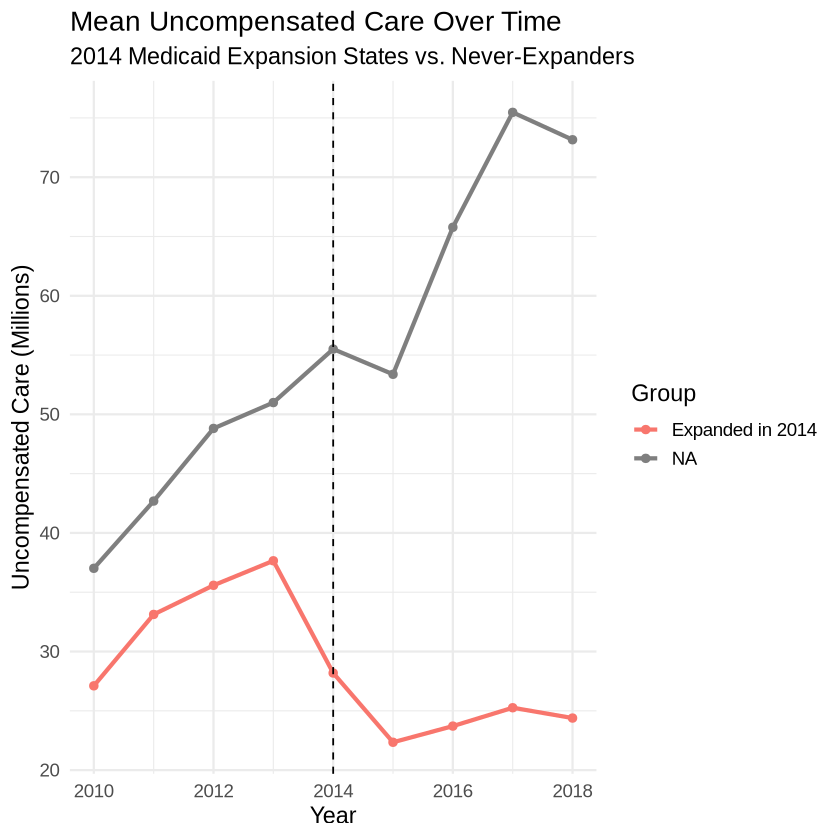

In [17]:
df <- hcris_kff %>% mutate(expansion_year = year(expansion_date), 
                           uncomp_care_m = uncomp_care / 1e6)

df_filtered <- df %>%
  filter(
    expansion_year == 2014 | is.na(expansion_year)   
      # keep 2014 expanders + never-expanders
  ) %>%
  mutate(
    group = if_else(expansion_year == 2014, "Expanded in 2014", "Never Expanded")
  )

df_summary <- df_filtered %>%
  group_by(year, group) %>%
  summarize(
    mean_uc = mean(uncomp_care_m, na.rm = TRUE),
    .groups = "drop"
  ) %>% filter(year>=2010, year<=2018)

ggplot(df_summary, aes(x = year, y = mean_uc, color = group)) +
  geom_line(size = 1.2) +
  geom_point(size = 2) +
  labs(
    title = "Mean Uncompensated Care Over Time",
    subtitle = "2014 Medicaid Expansion States vs. Never-Expanders",
    x = "Year",
    y = "Uncompensated Care (Millions)",
    color = "Group"
  ) +
  geom_vline(xintercept = 2014, linetype = "dashed") +
  theme_minimal(base_size = 14)

Yes, the graph does suggest a potential treatment effect. We note that the states with adoption in 2014 have decreased their amount of uncompensated care as opposed to states that are never-expanders or yet-to-expanders.

## Problem 3

In [18]:
df <- hcris_kff %>%
  mutate(
    expansion_year = year(expansion_date),
    uncomp_care_m = uncomp_care / 1e6,
    group = case_when(
      expansion_year == 2014 ~ "Treatment",
      is.na(expansion_year) ~ "Control"
    )
  ) %>%
  filter(group %in% c("Treatment", "Control"))  # drop post-2014 expanders

dd_table <- df %>%
  filter(year %in% c(2012, 2015)) %>%
  group_by(group, year) %>%
  summarize(
    mean_uc = mean(uncomp_care_m, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  tidyr::pivot_wider(
    names_from = year,
    values_from = mean_uc,
    names_prefix = "Year_"
  )

dd_table %>%
  mutate(
    Difference = Year_2015 - Year_2012
  ) %>%
  kable(
    col.names = c("Group", "2012 ($M)", "2015 ($M)", "Difference ($M)"),
    digits    = 2,
    booktabs  = TRUE,
    row.names = FALSE,
    caption   = "Difference-in-Differences: Mean Uncompensated Care (\\$M)"
  ) %>%
  kable_styling(latex_options = c("hold_position", "striped")) %>%
  column_spec(1, bold = TRUE) %>%
  row_spec(0, bold = TRUE)

<table class="table" style="margin-left: auto; margin-right: auto;">
<caption>Difference-in-Differences: Mean Uncompensated Care (\$M)</caption>
 <thead>
  <tr>
   <th style="text-align:left;font-weight: bold;"> Group </th>
   <th style="text-align:right;font-weight: bold;"> 2012 ($M) 
   </th>
<th style="text-align:right;font-weight: bold;"> 2015 ($M) </th>
   <th style="text-align:right;font-weight: bold;"> Difference ($M) </th>
  
 

</tr>
</thead>
<tbody>
  <tr>
   <td style="text-align:left;font-weight: bold;"> Control </td>
   <td style="text-align:right;"> 48.81 </td>
   <td style="text-align:right;"> 53.38 </td>
   <td style="text-align:right;"> 4.57 </td>
  </tr>
  <tr>
   <td style="text-align:left;font-weight: bold;"> Treatment </td>
   <td style="text-align:right;"> 35.58 </td>
   <td style="text-align:right;"> 22.35 </td>
   <td style="text-align:right;"> -13.24 </td>
  </tr>
</tbody>
</table>

## Problem 4

From the 2 by 2 DiD table, we note that states that might have adopted the Medicaid expansion policy in 2014 have decreased their amount of uncompensated care from 2012 to 2015, whereas never-expanders (or yet-to-expanders) in the control group have rather faced increased amounts of uncompensated care as observed. Thus, the adoption of Medicaid leads to a decrease in uncompensated care. Further, we expect this effect as it encourages hospitals to take Medicare patients and get compensation or partial support from the Medicare program, instead of outsourcing debt to manage or counter their listed charges to third parties, loaning ventures, or debt collector banks.

# Estimate ATEs

## Problem 5

In [19]:
hcris_kff <- hcris_kff %>% filter(uncomp_care > 0, year >= 2011, year <=2018)

df_dd <- hcris_kff %>%
  mutate(
    expansion_year = year(expansion_date),
    expand_ever    = if_else(!is.na(expansion_year), 1, 0),
    uncomp_care_m  = uncomp_care / 1e6,
    post           = if_else(year >= 2014, 1, 0),
    treat          = post * expand_ever
  ) %>%
  filter(
    expansion_year == 2014 | is.na(expansion_year)  # 2014 expanders + never-expanders
  )

model <- lm(uncomp_care_m ~ post + expand_ever + post * expand_ever, data = df_dd)

coef_df <- as.data.frame(summary(model)$coefficients)
coef_df$term <- c("Intercept", "Post 2014", "Ever Expanded", "Post x Ever Expanded (DiD)")
coef_df <- coef_df[, c("term", "Estimate", "Std. Error", "t value", "Pr(>|t|)")]

coef_df$`Pr(>|t|)` <- paste0(
  formatC(coef_df$`Pr(>|t|)`, format = "e", digits = 2), " ",
  symnum(coef_df$`Pr(>|t|)`, cutpoints = c(0, 0.01, 0.05, 0.1, 1), symbols = c("***", "**", "*", ""))
)

kable(
  coef_df,
  col.names = c("Term", "Estimate", "Std. Error", "t-Statistic", "p-Value"),
  digits    = 3,
  booktabs  = TRUE,
  row.names = FALSE,
  caption   = "DiD Estimates: Effect of Medicaid Expansion on Uncompensated Care (\\$M)"
) %>%
  kable_styling(latex_options = c("hold_position", "striped")) %>%
  column_spec(1, bold = TRUE) %>%
  row_spec(0, bold = TRUE) %>%
  row_spec(4, bold = TRUE) %>%
  add_footnote(
    c(paste0("Observations: ", nobs(model)),
      paste0("R-squared: ",    round(summary(model)$r.squared, 3)),
      "Signif. codes: *** p<0.01, ** p<0.05, * p<0.10"),
    notation = "none"
  )

<table class="table" style="margin-left: auto; margin-right: auto;">
<caption>DiD Estimates: Effect of Medicaid Expansion on Uncompensated Care (\$M)</caption>
 <thead>
  <tr>
   <th style="text-align:left;font-weight: bold;"> Term </th>
   <th style="text-align:right;font-weight: bold;"> Estimate </th>
   <th style="text-align:right;font-weight: bold;"> Std. Error </th>
   <th style="text-align:right;font-weight: bold;"> t-Statistic </th>
   <th style="text-align:left;font-weight: bold;"> p-Value </th>
  </tr>
 </thead>
<tbody>
  <tr>
   <td style="text-align:left;font-weight: bold;"> Intercept </td>
   <td style="text-align:right;"> 47.976 </td>
   <td style="text-align:right;"> 2.104 </td>
   <td style="text-align:right;"> 22.799 </td>
   <td style="text-align:left;"> 3.87e-113 *** </td>
  </tr>
  <tr>
   <td style="text-align:left;font-weight: bold;"> Post 2014 </td>
   <td style="text-align:right;"> 15.938 </td>
   <td style="text-align:right;"> 2.677 </td>
   <td style="text-alig

## Problem 6

In [20]:
library(fixest)

m.twfe <- feols(uncomp_care_m ~ treat | provider_number + year,
                data = df_dd,
                cluster = ~ state)

coef_twfe <- as.data.frame(summary(m.twfe)$coeftable)
coef_twfe$term <- "Treatment (DiD)"
coef_twfe <- coef_twfe[, c("term", "Estimate", "Std. Error", "t value", "Pr(>|t|)")]

coef_twfe$`Pr(>|t|)` <- paste0(
  formatC(coef_twfe$`Pr(>|t|)`, format = "e", digits = 2), " ",
  symnum(coef_twfe$`Pr(>|t|)`, cutpoints = c(0, 0.01, 0.05, 0.1, 1), symbols = c("***", "**", "*", ""))
)

kable(
  coef_twfe,
  col.names = c("Term", "Estimate", "Std. Error", "t-Statistic", "p-Value"),
  digits    = 3,
  booktabs  = TRUE,
  row.names = FALSE,
  caption   = "TWFE Estimates: Effect of Medicaid Expansion on Uncompensated Care (\\$M)"
) %>%
  kable_styling(latex_options = c("hold_position", "striped")) %>%
  column_spec(1, bold = TRUE) %>%
  row_spec(0, bold = TRUE) %>%
  add_footnote(
    c("Hospital and year fixed effects included.",
      "Standard errors clustered at the state level.",
      paste0("Observations: ", nobs(m.twfe)),
      paste0("R-squared (within): ", round(r2(m.twfe, type = "war2"), 3)),
      "Signif. codes: *** p<0.01, ** p<0.05, * p<0.10"),
    notation = "none"
  )

<table class="table" style="margin-left: auto; margin-right: auto;">
<caption>TWFE Estimates: Effect of Medicaid Expansion on Uncompensated Care (\$M)</caption>
 <thead>
  <tr>
   <th style="text-align:left;font-weight: bold;"> Term </th>
   <th style="text-align:right;font-weight: bold;"> Estimate </th>
   <th style="text-align:right;font-weight: bold;"> Std. Error </th>
   <th style="text-align:right;font-weight: bold;"> t-Statistic </th>
   <th style="text-align:left;font-weight: bold;"> p-Value </th>
  </tr>
 </thead>
<tbody>
  <tr>
   <td style="text-align:left;font-weight: bold;"> Treatment (DiD) </td>
   <td style="text-align:right;"> -30.755 </td>
   <td style="text-align:right;"> 5.903 </td>
   <td style="text-align:right;"> -5.21 </td>
   <td style="text-align:left;"> 7.36e-06 *** </td>
  </tr>
</tbody>
<tfoot>
<tr>
<td style = 'padding: 0; border:0;' colspan='100%'><sup></sup> Hospital and year fixed effects included.</td>
</tr>
<tr>
<td style = 'padding: 0; border:0;' colsp

We notice that both the estimators of Difference in Differences and Two-Way Fixed Effects yield near about same magnitude of estimated effect, around 26 to 30 million of uncompensated care in absolute magnitude, with the same number of observations and a statistically significant p-value.

## Problem 7

In [21]:
df_dd2 <- hcris_kff %>%
  mutate(
    expansion_year = year(expansion_date),
    expand_ever    = if_else(!is.na(expansion_year), 1, 0),
    uncomp_care_m  = uncomp_care / 1e6,
    post           = if_else(year >= 2014, 1, 0),
    treat          = if_else(!is.na(expansion_year) & year >= expansion_year, 1, 0)
  )

model2 <- lm(uncomp_care_m ~ post + expand_ever + post * expand_ever, data = df_dd2)

m.twfe2 <- feols(uncomp_care_m ~ treat | provider_number + year,
                 data = df_dd2,
                 cluster = ~ state)

# --- OLS Table ---
coef_ols2 <- as.data.frame(summary(model2)$coefficients)
coef_ols2$term <- c("Intercept", "Post 2014", "Ever Expanded", "Post x Ever Expanded (DiD)")
coef_ols2$`Pr(>|t|)` <- paste0(
  formatC(coef_ols2$`Pr(>|t|)`, format = "e", digits = 2), " ",
  symnum(coef_ols2$`Pr(>|t|)`, cutpoints = c(0, 0.01, 0.05, 0.1, 1), symbols = c("***", "**", "*", ""))
)
coef_ols2 <- coef_ols2[, c("term", "Estimate", "Std. Error", "t value", "Pr(>|t|)")]

kable(
  coef_ols2,
  col.names = c("Term", "Estimate", "Std. Error", "t-Statistic", "p-Value"),
  digits    = 3,
  booktabs  = TRUE,
  row.names = FALSE,
  caption   = "OLS DiD: Effect of Medicaid Expansion on Uncompensated Care (\\$M), All States"
) %>%
  kable_styling(latex_options = c("hold_position", "striped")) %>%
  column_spec(1, bold = TRUE) %>%
  row_spec(0, bold = TRUE) %>%
  row_spec(4, bold = TRUE) %>%
  add_footnote(
    c(paste0("Observations: ", nobs(model2)),
      paste0("R-squared: ", round(summary(model2)$r.squared, 3)),
      "Signif. codes: *** p<0.01, ** p<0.05, * p<0.10"),
    notation = "none"
  )

# --- TWFE Table ---
coef_twfe2 <- as.data.frame(summary(m.twfe2)$coeftable)
coef_twfe2$term <- "Treatment (DiD)"
coef_twfe2$`Pr(>|t|)` <- paste0(
  formatC(coef_twfe2$`Pr(>|t|)`, format = "e", digits = 2), " ",
  symnum(coef_twfe2$`Pr(>|t|)`, cutpoints = c(0, 0.01, 0.05, 0.1, 1), symbols = c("***", "**", "*", ""))
)
coef_twfe2 <- coef_twfe2[, c("term", "Estimate", "Std. Error", "t value", "Pr(>|t|)")]

kable(
  coef_twfe2,
  col.names = c("Term", "Estimate", "Std. Error", "t-Statistic", "p-Value"),
  digits    = 3,
  booktabs  = TRUE,
  row.names = FALSE,
  caption   = "TWFE: Effect of Medicaid Expansion on Uncompensated Care (\\$M), All States"
) %>%
  kable_styling(latex_options = c("hold_position", "striped")) %>%
  column_spec(1, bold = TRUE) %>%
  row_spec(0, bold = TRUE) %>%
  add_footnote(
    c("Hospital and year fixed effects included.",
      "Standard errors clustered at the state level.",
      paste0("Observations: ", nobs(m.twfe2)),
      paste0("R-squared (within): ", round(r2(m.twfe2, type = "war2"), 3)),
      "Signif. codes: *** p<0.01, ** p<0.05, * p<0.10"),
    notation = "none"
  )

<table class="table" style="margin-left: auto; margin-right: auto;">
<caption>OLS DiD: Effect of Medicaid Expansion on Uncompensated Care (\$M), All States</caption>
 <thead>
  <tr>
   <th style="text-align:left;font-weight: bold;"> Term </th>
   <th style="text-align:right;font-weight: bold;"> Estimate </th>
   <th style="text-align:right;font-weight: bold;"> Std. Error </th>
   <th style="text-align:right;font-weight: bold;"> t-Statistic </th>
   <th style="text-align:left;font-weight: bold;"> p-Value </th>
  </tr>
 </thead>
<tbody>
  <tr>
   <td style="text-align:left;font-weight: bold;"> Intercept </td>
   <td style="text-align:right;"> 47.976 </td>
   <td style="text-align:right;"> 3.643 </td>
   <td style="text-align:right;"> 13.171 </td>
   <td style="text-align:left;"> 1.88e-39 *** </td>
  </tr>
  <tr>
   <td style="text-align:left;font-weight: bold;"> Post 2014 </td>
   <td style="text-align:right;"> 15.938 </td>
   <td style="text-align:right;"> 4.635 </td>
   <td style="text

<table class="table" style="margin-left: auto; margin-right: auto;">
<caption>TWFE: Effect of Medicaid Expansion on Uncompensated Care (\$M), All States</caption>
 <thead>
  <tr>
   <th style="text-align:left;font-weight: bold;"> Term </th>
   <th style="text-align:right;font-weight: bold;"> Estimate </th>
   <th style="text-align:right;font-weight: bold;"> Std. Error </th>
   <th style="text-align:right;font-weight: bold;"> t-Statistic </th>
   <th style="text-align:left;font-weight: bold;"> p-Value </th>
  </tr>
 </thead>
<tbody>
  <tr>
   <td style="text-align:left;font-weight: bold;"> Treatment (DiD) </td>
   <td style="text-align:right;"> -23.609 </td>
   <td style="text-align:right;"> 4.736 </td>
   <td style="text-align:right;"> -4.985 </td>
   <td style="text-align:left;"> 7.54e-06 *** </td>
  </tr>
</tbody>
<tfoot>
<tr>
<td style = 'padding: 0; border:0;' colspan='100%'><sup></sup> Hospital and year fixed effects included.</td>
</tr>
<tr>
<td style = 'padding: 0; border:0;' co

Yes, the results vary slightly when we include all states (even those that expanded after 2014). We notice a lower absolute value of uncompensated care since this cumulatively aggregates all the treatment effects across the different states, including those that might have (and would have) different adoption years, or might not have expanded ever. This doesn't take into account that the number of control years could then vary according to the year of adoption, and similarly, the years of post-adoption would be different too. Further, unvieling TWFE as a biased estimator.

## Problem 8

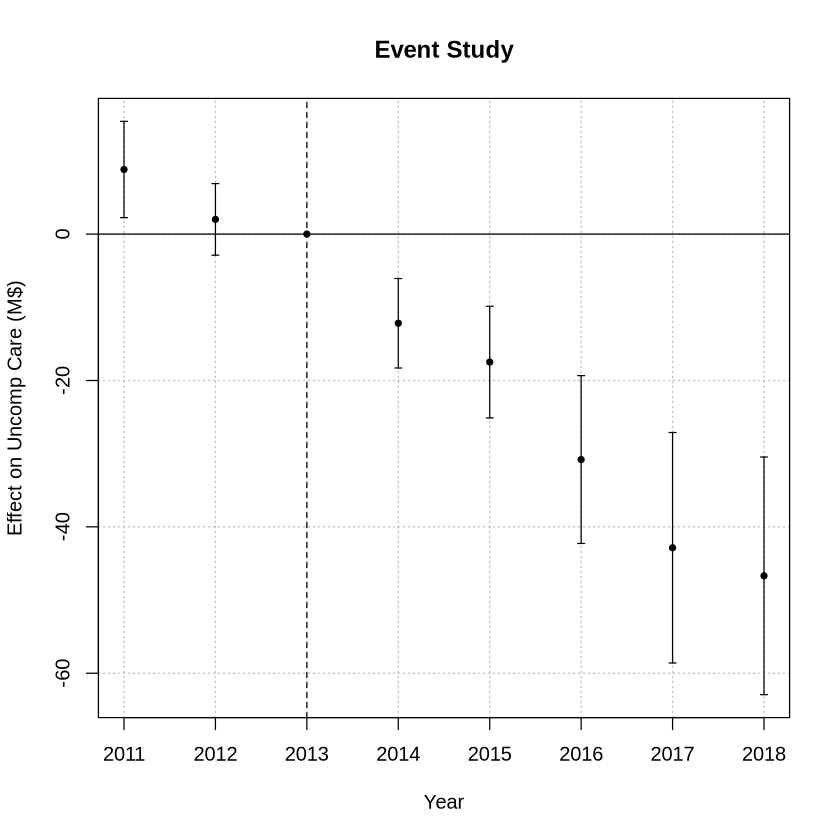

In [22]:
mod.twfe3 <- feols(uncomp_care_m ~ i(year, expand_ever, ref = 2013) | provider_number + year,
                  cluster = ~ state,
                  data = df_dd)

iplot(mod.twfe3,
      xlab = "Year",
      ylab = "Effect on Uncomp Care (M$)",
      main = "Event Study")

## Problem 9

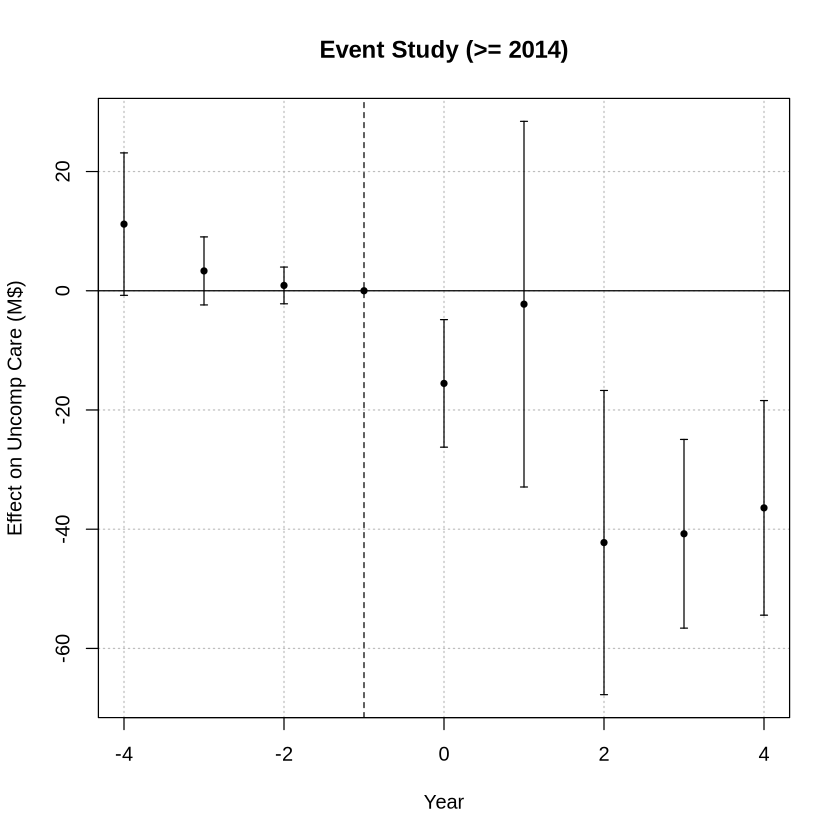

In [23]:
df_dd3 <- hcris_kff %>%
  mutate(
    expansion_year = year(expansion_date),
    expand_ever    = if_else(!is.na(expansion_year), 1, 0),
    uncomp_care_m  = uncomp_care / 1e6,
    # time relative to EACH STATE'S expansion year
    event_time     = year - expansion_year
    # never-expanders get NA here
  )

df_dd3 <- df_dd3 %>%
  mutate(
    event_time = case_when(
      is.na(expansion_year) ~ -1,   # never-expanders coded as "always pre"
      event_time < -4 ~ -4,          # bin anything beyond -4 into -4
      event_time > 4  ~  4,          # bin anything beyond +4 into +4
      TRUE ~ event_time
    )
  )

mod.twfe4 <- feols(
  uncomp_care_m ~ i(event_time, expand_ever, ref = -1) | provider_number + year,
  cluster = ~ state,
  data = df_dd3
)

iplot(mod.twfe4,
      xlab = "Year",
      ylab = "Effect on Uncomp Care (M$)",
      main = "Event Study (>= 2014)")

## Problem 10

Medicaid expansion leads to a decrease in uncompensated care for hospitals in states that have adopted the change in policy. Event study graphs are concerning when the bars for pre-treatment deviate considerably far from the zero margin, showing a violation of the parallel trends assumption. However, in our case, we see the confidence interval of our pre-treatment variates to include 0 and further congregate around zero margin on average, following which, when treatment comes into effect, we do see a significant effect of a downward slope. The invocation of the event time as opposed to a simple calendar year takes care of the previous bias of different states having different adoption years, and further portrays and brings a more centralized angle to this analysis as opposed to the primary limitation of the TWFE estimator being biased in nature, particularly because of lacking this staggered time context. Furthermore, the binning effect around the ends accounts for aggregating the effect of states that might have accumulatively expanded over a certain period but not over another, so this spreads out the congregated effect and accurately captures the right treatment effect, being more granular instead of biasing towards particular years and states.